# Auditor Agent — GRPO Training
Trains the Auditor agent to classify invoices as `approved` or `flagged` with fraud type.
Uses the same live HF Space `/multi/audit` endpoint as the reward verifier.

**Model:** Qwen2.5-1.5B-Instruct, 4-bit QLoRA, r=16  
**Reward:** +0.99 correct fraud (right type), +0.90 clean clearance, +0.01 miss/FP  
**Environment:** https://ps2181-invoice-processing-pipeline.hf.space

In [ ]:
# Cell 1 — Install
!pip install -q -U accelerate trl
!pip install -q unsloth transformers peft datasets httpx matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 697.4/697.4 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 52.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 21.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 131.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 49.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 421.9/421.9 kB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 111.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 119.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
# Cell 2 — Imports
import json
import random
import re
import httpx
from datasets import Dataset

ENV_URL = "https://ps2181-invoice-processing-pipeline.hf.space"

SYSTEM_PROMPT = """You are an invoice fraud auditor. You will be given a batch of invoices and reference data.
Review each invoice and output a JSON array called audit_results.

For each invoice output:
{"invoice_id": "INV-XXXXX", "verdict": "approved" or "flagged", "fraud_type": null or one of ["phantom_vendor", "price_gouging", "math_fraud", "duplicate_submission"], "confidence": 0.0-1.0}

Rules:
- phantom_vendor: vendor not in the Approved Vendor Registry
- price_gouging: unit price > 150% of market max price in catalog
- math_fraud: invoice total does not equal sum of line item amounts
- duplicate_submission: same invoice_id or vendor+date+total already in invoice history

Output ONLY valid JSON: {\"audit_results\": [...]}"""

In [ ]:
# Cell 3 — Load model
from unsloth import FastLanguageModel
import torch

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="unsloth/Qwen2.5-1.5B-Instruct",
    max_seq_length=2048,
    dtype=None,
    load_in_4bit=True,
)

model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
    lora_alpha=16,
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=42,
)
print("Model loaded")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/1.53G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/270 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

unsloth/qwen2.5-1.5b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth 2026.4.8 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


Model loaded


In [ ]:
# Cell 4 — Reward functions

def _parse_audit_json(text: str):
    """Extract audit_results list from model output."""
    text = text.strip()
    # Strip markdown code fences
    if text.startswith("```"):
        text = re.sub(r"^```[a-z]*\n?", "", text)
        text = re.sub(r"```$", "", text).strip()
    try:
        d = json.loads(text)
        if isinstance(d, dict):
            return d.get("audit_results", [])
        if isinstance(d, list):
            return d
    except json.JSONDecodeError:
        pass
    return []


def reward_auditor_local(completions, ground_truth=None, **kwargs):
    """
    Local reward: scores audit_results against ground truth without calling the server.
    ground_truth: list of {invoice_id, verdict, fraud_type}
    """
    rewards = []
    if ground_truth is None:
        return [0.01] * len(completions)

    gt_list = ground_truth if isinstance(ground_truth, list) else [ground_truth]
    gt_map = {g["invoice_id"]: g for g in gt_list}

    for completion in completions:
        text = completion[0]["content"] if isinstance(completion, list) else completion
        audit_results = _parse_audit_json(text)

        if not audit_results:
            rewards.append(0.01)
            continue

        total = 0.0
        count = 0
        for result in audit_results:
            inv_id = result.get("invoice_id", "")
            gt = gt_map.get(inv_id)
            if gt is None:
                continue
            count += 1
            pred_verdict = result.get("verdict", "").lower()
            pred_ftype = result.get("fraud_type")
            true_verdict = gt["verdict"]
            true_ftype = gt["fraud_type"]

            is_fraud = true_verdict == "flagged"
            pred_flagged = pred_verdict == "flagged"

            if is_fraud and pred_flagged and pred_ftype == true_ftype:
                total += 0.99
            elif not is_fraud and not pred_flagged:
                total += 0.90
            elif is_fraud and pred_flagged:
                total += 0.50  # right direction, wrong type
            else:
                total += 0.01  # miss or false positive

        reward = round(total / count, 4) if count > 0 else 0.01
        rewards.append(max(0.01, min(reward, 0.99)))

    return rewards


def reward_format_audit(completions, **kwargs):
    """Check that output is valid JSON with audit_results key."""
    rewards = []
    for completion in completions:
        text = completion[0]["content"] if isinstance(completion, list) else completion
        results = _parse_audit_json(text)
        if results and isinstance(results, list) and all("invoice_id" in r for r in results):
            rewards.append(0.20)
        elif results:
            rewards.append(0.10)
        else:
            rewards.append(0.01)
    return rewards


def reward_live_environment(completions, episode_id=None, **kwargs):
    rewards = []
    episode_ids = episode_id if isinstance(episode_id, list) else [episode_id] * len(completions)
    for i, completion in enumerate(completions):
        ep_id = episode_ids[i] if i < len(episode_ids) else None
        if not ep_id:
            rewards.append(0.01)
            continue
        text = completion[0]["content"] if isinstance(completion, list) else completion
        audit_results = _parse_audit_json(text)
        if not audit_results:
            rewards.append(0.01)
            continue
        try:
            resp = httpx.post(
                f"{ENV_URL}/multi/audit",
                json={"episode_id": ep_id, "audit_results": audit_results},
                timeout=15,
            )
            data = resp.json()
            rewards.append(float(data.get("mean_reward", 0.01)))
        except Exception:
            rewards.append(0.01)
    return rewards

In [ ]:
import httpx, time

ENV_URL = "https://ps2181-invoice-processing-pipeline.hf.space"

# Test with a single request
print("Testing /multi/reset latency...")
t0 = time.time()
try:
    r = httpx.post(f"{ENV_URL}/multi/reset", timeout=30)
    elapsed = time.time() - t0
    print(f"Single request: {elapsed:.2f}s, status={r.status_code}")
except Exception as e:
    elapsed = time.time() - t0
    print(f"Single request FAILED after {elapsed:.2f}s: {e}")

# Quick health check
print("\nTesting /health...")
t0 = time.time()
try:
    r = httpx.get(f"{ENV_URL}/health", timeout=10)
    elapsed = time.time() - t0
    print(f"Health: {elapsed:.2f}s, status={r.status_code}")
except Exception as e:
    print(f"Health FAILED: {e}")

Testing /multi/reset latency...
Single request: 0.46s, status=200

Testing /health...
Health: 0.35s, status=200


In [ ]:
import asyncio
import httpx
import time
from datasets import Dataset

async def fetch_single_episode(client, system_prompt, tokenizer):
    """Fetches a single episode and prepares the prompt structure."""
    try:
        resp = await client.post(f"{ENV_URL}/multi/reset", timeout=15)
        resp.raise_for_status()
        data = resp.json()

        user_prompt = (
            f"INVOICE BATCH:\n{data['raw_text'][:800]}\n\n"
            f"REFERENCE DATA:\n{data.get('reference_data', '')[:400]}\n\n"
            "Audit all invoices. Output: {\"audit_results\": [...]}"
        )

        # Token validation
        full_text = system_prompt + user_prompt
        if len(tokenizer.encode(full_text)) > 1024:
            return None

        return {
            "prompt": [
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_prompt},
            ],
            "episode_id": data["episode_id"],
            "fraud_weights": str(data.get("fraud_weights_used", {})),
        }
    except Exception:
        return None

async def sample_auditor_episodes_async(n=80, max_concurrent=10):
    """Samples episodes concurrently to drastically reduce wait time."""
    limits = httpx.Limits(max_keepalive_connections=5, max_connections=max_concurrent)
    async with httpx.AsyncClient(limits=limits) as client:
        tasks = [fetch_single_episode(client, SYSTEM_PROMPT, tokenizer) for _ in range(n)]
        results = await asyncio.gather(*tasks)

    # Filter out None values (errors or token overflows)
    valid_episodes = [res for res in results if res is not None]
    print(f"Sampled {len(valid_episodes)} valid auditor episodes.")
    return valid_episodes

# --- Execution ---
# Run the async sampler
episodes = await sample_auditor_episodes_async(n=80)

# Smart Upsampling: If we fall short of 40, duplicate until we hit the target
if 0 < len(episodes) < 40:
    multiplier = (40 // len(episodes)) + 1
    episodes = (episodes * multiplier)[:80]

dataset = Dataset.from_list(episodes)
print(f"Dataset: {len(dataset)} rows")

Sampled 80 valid auditor episodes.
Dataset: 80 rows


In [ ]:
# Cell 6 — Configure and run GRPO training
from trl import GRPOConfig, GRPOTrainer

training_args = GRPOConfig(
    max_steps=30,                      # was 50 — stop before collapse
    per_device_train_batch_size=1,
    gradient_accumulation_steps=4,
    num_generations=4,
    max_prompt_length=1024,            # Increased from 512 to 1024
    max_completion_length=512,
    learning_rate=5e-6,
    logging_steps=5,                   # was 10 — finer granularity
    save_steps=5,                      # NEW — save every 5 steps
    output_dir="auditor_grpo_output",
    report_to="none",
    temperature=0.7,                   # was 0.9 — slightly more focused
    beta=0.001,
)

trainer = GRPOTrainer(
    model=model,
    processing_class=tokenizer,
    args=training_args,
    train_dataset=dataset,
    reward_funcs=[
        reward_format_audit,        # JSON format check (keeps gradient signal)
        reward_live_environment,    # live HF Space verifier (the truth)
        # reward_auditor_local REMOVED — was returning [0.01]*N flat
        #                       (no ground_truth was passed at sample time)
    ],
)

print("Starting Auditor GRPO training...")
print("Watch: format climbs first, then live_env reward when format stabilizes")
trainer.train()

Starting Auditor GRPO training...
Watch: format climbs first, then live_env reward when format stabilizes


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 80 | Num Epochs = 1 | Total steps = 30
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 4 x 1) = 4
 "-____-"     Trainable parameters = 18,464,768 of 1,562,179,072 (1.18% trained)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3

Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / reward_format_audit / mean,rewards / reward_format_audit / std,rewards / reward_live_environment / mean,rewards / reward_live_environment / std
5,0.000000,0.482750,0.194365,127.850000,123.400000,131.000000,0.000000,127.850000,123.400000,131.000000,0.000003,0.200000,0.000000,0.282750,0.194365
10,0.000000,0.718750,0.239377,106.450000,101.400000,110.600000,0.000000,106.450000,101.400000,110.600000,0.000025,0.200000,0.000000,0.518750,0.239377
15,0.000000,0.453835,0.123136,125.800000,116.200000,131.000000,0.000000,125.800000,116.200000,131.000000,0.000051,0.200000,0.000000,0.253835,0.123136
20,0.000000,0.573340,0.212295,125.300000,114.400000,131.000000,0.000000,125.300000,114.400000,131.000000,0.000099,0.200000,0.000000,0.373340,0.212295
25,0.000000,0.532500,0.231516,127.300000,125.000000,130.000000,0.000000,127.300000,125.000000,130.000000,0.000129,0.200000,0.000000,0.332500,0.231516
30,0.000000,0.603755,0.147087,135.700000,129.800000,139.800000,0.000000,135.700000,129.800000,139.800000,0.000151,0.200000,0.000000,0.403755,0.147087


Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

TrainOutput(global_step=30, training_loss=6.745879848798116e-08, metrics={'train_runtime': 472.7307, 'train_samples_per_second': 0.254, 'train_steps_per_second': 0.063, 'total_flos': 0.0, 'train_loss': 6.745879848798116e-08})

In [ ]:
# Cell 7 — Before/after comparison (shows learning)
# Seed the tracker with demo data first so we have a baseline
httpx.post(f"{ENV_URL}/regulator/demo_seed")

from unsloth import FastLanguageModel
FastLanguageModel.for_inference(model)

def run_auditor_eval(n_episodes=10, label=""):
    """Run n episodes, submit audit, collect mean rewards."""
    rewards = []
    for _ in range(n_episodes):
        try:
            ep = httpx.post(f"{ENV_URL}/multi/reset", timeout=15).json()
            episode_id = ep["episode_id"]
            raw_text = ep["raw_text"]
            ref_data = ep.get("reference_data", "")

            user_prompt = (
                f"INVOICE BATCH:\n{raw_text[:800]}\n\n"
                f"REFERENCE DATA:\n{ref_data[:400]}\n\n"
                "Audit all invoices. Output: {\"audit_results\": [...]}"
            )

            inputs = tokenizer.apply_chat_template(
                [{"role": "system", "content": SYSTEM_PROMPT},
                 {"role": "user", "content": user_prompt}],
                tokenize=True, add_generation_prompt=True,
                return_tensors="pt"
            ).to(model.device)

            output = model.generate(
                inputs, max_new_tokens=400, temperature=0.3, do_sample=True
            )
            text = tokenizer.decode(output[0][inputs.shape[1]:], skip_special_tokens=True)

            audit_results = _parse_audit_json(text)
            if not audit_results:
                rewards.append(0.01)
                continue

            resp = httpx.post(
                f"{ENV_URL}/multi/audit",
                json={"episode_id": episode_id, "audit_results": audit_results},
                timeout=15,
            ).json()
            rewards.append(resp.get("mean_reward", 0.01))
        except Exception as e:
            print(f"Error: {e}")
            rewards.append(0.01)

    avg = sum(rewards) / len(rewards) if rewards else 0.0
    print(f"{label} | n={len(rewards)} | mean_auditor_reward={avg:.3f} | per_ep={[round(r,2) for r in rewards]}")
    return avg


print("=== POST-TRAINING EVAL ===")
after_score = run_auditor_eval(n_episodes=10, label="After GRPO (50 steps)")

# Check regulator report — did phantom_vendor detection improve?
report = httpx.get(f"{ENV_URL}/regulator/report").json()
print("\n=== REGULATOR REPORT AFTER TRAINING ===")
for ft, status in report["detection_rates"].items():
    print(f"  {ft:<28} {status}")
print(f"\nBlind spots: {report['blind_spots']}")
print(f"Verdict: {report['verdict']}")

=== POST-TRAINING EVAL ===


Both `max_new_tokens` (=400) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=4

After GRPO (50 steps) | n=10 | mean_auditor_reward=0.524 | per_ep=[0.99, 0.5, 0.99, 0.26, 0.74, 0.26, 0.26, 0.5, 0.5, 0.26]

=== REGULATOR REPORT AFTER TRAINING ===
  phantom_vendor               50%  ⚡ EMERGING (0.00↓)
  price_gouging                72%  ✓ OK (-0.60↓)
  math_fraud                   74%  ✓ OK (-0.80↓)
  duplicate_submission         58%  ⚡ EMERGING (0.00↓)

Blind spots: []
Verdict: Auditor performance OK across all fraud types


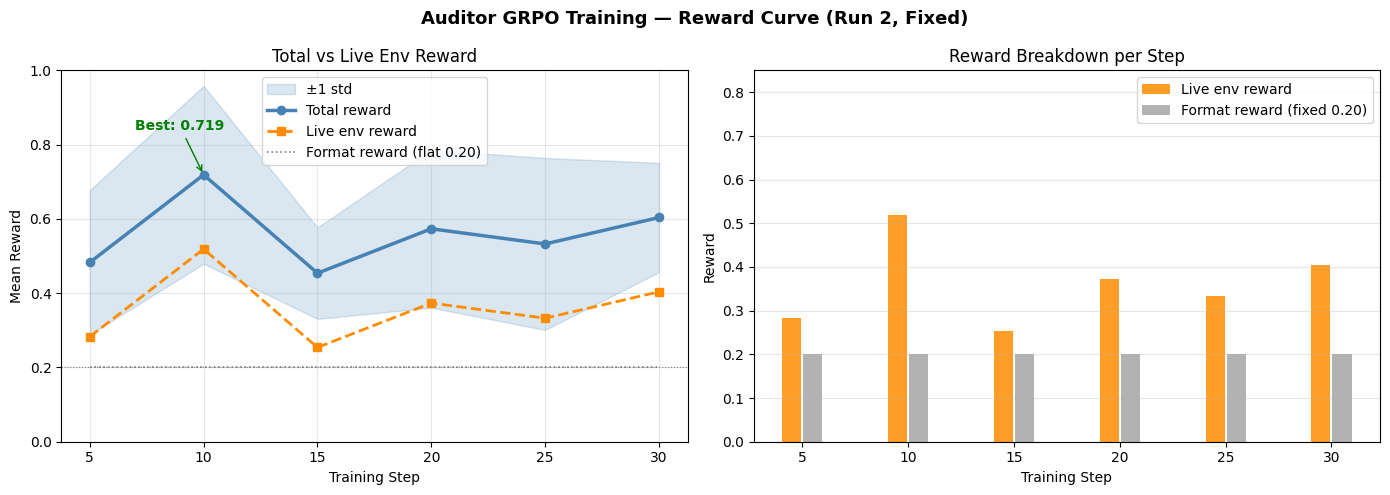

Saved: auditor_reward_curve_run2.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ── Exact data from training log ──────────────────────────────────────────────
steps          = [5,        10,       15,       20,       25,       30]
total_reward   = [0.482750, 0.718750, 0.453835, 0.573340, 0.532500, 0.603755]
reward_std     = [0.194365, 0.239377, 0.123136, 0.212295, 0.231516, 0.147087]
live_env       = [0.282750, 0.518750, 0.253835, 0.373340, 0.332500, 0.403755]
format_reward  = [0.200,    0.200,    0.200,    0.200,    0.200,    0.200]   # flat

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Auditor GRPO Training — Reward Curve (Run 2, Fixed)", fontsize=13, fontweight="bold")

# ── Left: Total reward + std band ────────────────────────────────────────────
ax = axes[0]
ax.fill_between(steps,
                [r - s for r, s in zip(total_reward, reward_std)],
                [r + s for r, s in zip(total_reward, reward_std)],
                alpha=0.2, color="steelblue", label="±1 std")
ax.plot(steps, total_reward,  marker="o", lw=2.5, color="steelblue", label="Total reward")
ax.plot(steps, live_env,      marker="s", lw=2,   color="darkorange", linestyle="--", label="Live env reward")
ax.plot(steps, format_reward, marker="",  lw=1.2, color="gray",       linestyle=":",  label="Format reward (flat 0.20)")
ax.axhline(y=0.20, color="gray", lw=0.8, linestyle=":")
ax.set_xlabel("Training Step"); ax.set_ylabel("Mean Reward")
ax.set_title("Total vs Live Env Reward")
ax.set_ylim(0, 1.0); ax.legend(); ax.grid(True, alpha=0.3)

# Annotate best step
best_idx = total_reward.index(max(total_reward))
ax.annotate(f"Best: {max(total_reward):.3f}",
            xy=(steps[best_idx], total_reward[best_idx]),
            xytext=(steps[best_idx] - 3, total_reward[best_idx] + 0.12),
            arrowprops=dict(arrowstyle="->", color="green"), color="green", fontweight="bold")

# ── Right: Breakdown — live env vs format ────────────────────────────────────
ax2 = axes[1]
ax2.bar(np.array(steps) - 0.5, live_env,      width=0.9, color="darkorange", alpha=0.85, label="Live env reward")
ax2.bar(np.array(steps) + 0.5, format_reward, width=0.9, color="gray",       alpha=0.60, label="Format reward (fixed 0.20)")
ax2.set_xlabel("Training Step"); ax2.set_ylabel("Reward")
ax2.set_title("Reward Breakdown per Step")
ax2.set_xticks(steps); ax2.set_ylim(0, 0.85)
ax2.legend(); ax2.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("auditor_reward_curve_run2.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: auditor_reward_curve_run2.png")


In [ ]:
# Cell 9 — Pick best Auditor checkpoint, clean it, push to Hub
import os, shutil, json

ckpt_dir = "auditor_grpo_output"
checkpoints = sorted(
    [d for d in os.listdir(ckpt_dir) if d.startswith("checkpoint-")],
    key=lambda x: int(x.split("-")[1])
)
print(f"Checkpoints on disk: {checkpoints}")

# Inspect rewards by step from training log
log_history = trainer.state.log_history
reward_logs = [x for x in log_history if "reward" in x and "step" in x]

print("\nReward by step:")
for r in reward_logs:
    step = r["step"]
    total = r.get("reward", 0)
    fmt = r.get("rewards/reward_format_audit/mean", 0)
    live = r.get("rewards/reward_live_environment/mean", 0)
    print(f"  step {step:3d}: total={total:.3f}  format={fmt:.3f}  live={live:.3f}")

# Pick by TOTAL reward (more robust than picking on a single signal)
# Tie-breaker: highest step (more training)
best_log = max(
    reward_logs,
    key=lambda x: (x.get("reward", 0), x.get("step", 0))
)
best_step = best_log["step"]
print(f"\nBest step: {best_step} (total={best_log.get('reward', 0):.3f}, "
      f"live={best_log.get('rewards/reward_live_environment/mean', 0):.3f})")

# Map best step to closest *saved* checkpoint
saved_steps = [int(c.split("-")[1]) for c in checkpoints]
chosen_step = min(saved_steps, key=lambda s: abs(s - best_step))
chosen_ckpt = f"{ckpt_dir}/checkpoint-{chosen_step}"
print(f"Closest saved checkpoint: {chosen_ckpt}")

# Build clean adapter folder
final_dir = "auditor_lora"
if os.path.exists(final_dir):
    shutil.rmtree(final_dir)
shutil.copytree(chosen_ckpt, final_dir)

# Strip training-state files (not needed for inference, just bloat)
for f in ["optimizer.pt", "rng_state.pth", "scaler.pt", "scheduler.pt",
          "trainer_state.json", "training_args.bin"]:
    p = f"{final_dir}/{f}"
    if os.path.exists(p):
        os.remove(p)
        print(f"  removed {f}")

# Add tokenizer (checkpoints don't include it)
tokenizer.save_pretrained(final_dir)

# Patch base model name for portability (so non-4bit envs can load it)
cfg_path = f"{final_dir}/adapter_config.json"
with open(cfg_path) as f:
    cfg = json.load(f)
if "unsloth" in cfg.get("base_model_name_or_path", "").lower() or "4bit" in cfg.get("base_model_name_or_path", "").lower():
    cfg["base_model_name_or_path"] = "Qwen/Qwen2.5-1.5B-Instruct"
    with open(cfg_path, "w") as f:
        json.dump(cfg, f, indent=2)
    print(f"  patched base_model_name_or_path → Qwen/Qwen2.5-1.5B-Instruct")

# Verify final contents
print(f"\n✓ Final {final_dir}/ ready (from checkpoint-{chosen_step}):")
total_mb = 0
for f in sorted(os.listdir(final_dir)):
    size_mb = os.path.getsize(f"{final_dir}/{f}") / 1e6
    total_mb += size_mb
    print(f"  {f}  ({size_mb:.2f} MB)")
print(f"\nTotal: {total_mb:.2f} MB")

# Hash check (proves which checkpoint we're shipping)
import hashlib
def file_hash(path):
    h = hashlib.md5()
    with open(path, "rb") as f:
        while chunk := f.read(8192):
            h.update(chunk)
    return h.hexdigest()[:12]

target_hash = file_hash(f"{final_dir}/adapter_model.safetensors")
ckpt_hash = file_hash(f"{chosen_ckpt}/adapter_model.safetensors")
match = "✓ MATCH" if target_hash == ckpt_hash else "✗ MISMATCH"
print(f"\nHash check: {match}")
print(f"  {final_dir}: {target_hash}")
print(f"  {chosen_ckpt}: {ckpt_hash}")

Checkpoints on disk: ['checkpoint-5', 'checkpoint-10', 'checkpoint-15', 'checkpoint-20', 'checkpoint-25', 'checkpoint-30']

Reward by step:
  step   5: total=0.483  format=0.200  live=0.283
  step  10: total=0.719  format=0.200  live=0.519
  step  15: total=0.454  format=0.200  live=0.254
  step  20: total=0.573  format=0.200  live=0.373
  step  25: total=0.532  format=0.200  live=0.332
  step  30: total=0.604  format=0.200  live=0.404

Best step: 10 (total=0.719, live=0.519)
Closest saved checkpoint: auditor_grpo_output/checkpoint-10
  removed optimizer.pt
  removed rng_state.pth
  removed scaler.pt
  removed scheduler.pt
  removed trainer_state.json
  removed training_args.bin


Unsloth: Restored added_tokens_decoder metadata in auditor_lora/tokenizer_config.json.


  patched base_model_name_or_path → Qwen/Qwen2.5-1.5B-Instruct

✓ Final auditor_lora/ ready (from checkpoint-10):
  README.md  (0.01 MB)
  adapter_config.json  (0.00 MB)
  adapter_model.safetensors  (73.91 MB)
  chat_template.jinja  (0.00 MB)
  tokenizer.json  (11.42 MB)
  tokenizer_config.json  (0.00 MB)

Total: 85.35 MB

Hash check: ✓ MATCH
  auditor_lora: d5c7c11deda5
  auditor_grpo_output/checkpoint-10: d5c7c11deda5


In [ ]:
# Cell 10 — Push Auditor to Hugging Face Hub
from huggingface_hub import login, HfApi, whoami

TOKEN = "HF_token"  # same token you used for Generator

login(token=TOKEN, add_to_git_credential=False)
me = whoami(token=TOKEN)
USERNAME = me["name"]

REPO_ID = f"{USERNAME}/auditor-lora-qwen2.5-1.5b"
print(f"Pushing to: {REPO_ID}")

api = HfApi()
api.create_repo(repo_id=REPO_ID, repo_type="model", exist_ok=True, token=TOKEN)
api.upload_folder(
    folder_path="auditor_lora",
    repo_id=REPO_ID,
    repo_type="model",
    commit_message=f"Auditor GRPO best checkpoint",
    token=TOKEN,
)
print(f"\n✓ https://huggingface.co/{REPO_ID}")

Pushing to: ps2181/auditor-lora-qwen2.5-1.5b


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...ditor_lora/tokenizer.json: 100%|##########| 11.4MB / 11.4MB            

  ...adapter_model.safetensors:   0%|          | 45.7kB / 73.9MB            


✓ https://huggingface.co/ps2181/auditor-lora-qwen2.5-1.5b
